In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

masoudnickparvar_brain_tumor_mri_dataset_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
mahmoudhassaann_xception_tensorflow2_default_1_path = kagglehub.model_download('mahmoudhassaann/xception/TensorFlow2/default/1')

print('Data source import complete.')



  0%|          | 0.00/79.8M [00:00<?, ?B/s]
  1%|▏         | 1.00M/79.8M [00:01<01:54, 719kB/s]
  3%|▎         | 2.00M/79.8M [00:01<00:58, 1.39MB/s]
  4%|▍         | 3.00M/79.8M [00:01<00:36, 2.21MB/s]
  5%|▌         | 4.00M/79.8M [00:01<00:24, 3.20MB/s]
  8%|▊         | 6.00M/79.8M [00:02<00:14, 5.47MB/s]
 10%|█         | 8.00M/79.8M [00:02<00:09, 7.82MB/s]
 13%|█▎        | 10.0M/79.8M [00:02<00:07, 9.67MB/s]
 15%|█▌        | 12.0M/79.8M [00:02<00:06, 11.3MB/s]
 18%|█▊        | 14.0M/79.8M [00:02<00:05, 12.6MB/s]
 20%|██        | 16.0M/79.8M [00:02<00:04, 13.4MB/s]
 23%|██▎       | 18.0M/79.8M [00:02<00:04, 14.5MB/s]
 25%|██▌       | 20.0M/79.8M [00:03<00:04, 14.6MB/s]
 28%|██▊       | 22.0M/79.8M [00:03<00:04, 15.1MB/s]
 30%|███       | 24.0M/79.8M [00:03<00:03, 15.2MB/s]
 33%|███▎      | 26.0M/79.8M [00:03<00:03, 15.9MB/s]
 35%|███▌      | 28.0M/79.8M [00:03<00:03, 15.4MB/s]
 38%|███▊      | 30.0M/79.8M [00:03<00:03, 15.9MB/s]
 40%|████      | 32.0M/79.8M [00:03<00:03, 16.3MB/s]
 4

Data source import complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Activation, MaxPooling2D, Flatten, Dense , Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
import random
import pandas as pd
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,precision_score, recall_score, f1_score,classification_report
from tensorflow.keras.optimizers import Adamax
import keras
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from os import listdir

In [ ]:
base_directory = '/kaggle/input/brain-tumor-mri-dataset'
Training , Testing = 'Training', 'Testing'
List_labels = os.listdir(base_directory+'/'+Training)
target_size = (299 , 299)
num_classes = 4
labels = {}
for key in range(len(list(List_labels))):
    labels[List_labels[key]] = key

In [ ]:
labels


{'pituitary': 0, 'notumor': 1, 'meningioma': 2, 'glioma': 3}

In [ ]:
def plot_sample_iamges(dataset_type , num_images = 4 , target_size = (299 ,299)):

    datasetpath = os.path.join(base_directory , dataset_type)

    fig, axes = plt.subplots(len(List_labels), num_images, figsize=(15, 10))


    for row,label in enumerate(List_labels):

        category_path = os.path.join(datasetpath, label)

        image_filenames = random.sample(os.listdir(category_path) , num_images)

        for col , image_filename in enumerate(image_filenames):
          while image_filename == '.DS_Store':
                image_filename = random.sample(os.listdir(category_path), 1)[0]
          image_path = os.path.join(category_path , image_filename)
          image = Image.open(image_path).resize(target_size)
          axes[row, col].imshow(image, cmap='gray')
          axes[row, col].axis('off')
          axes[row, col].set_title(f"{label}")

    plt.tight_layout()
    plt.show()

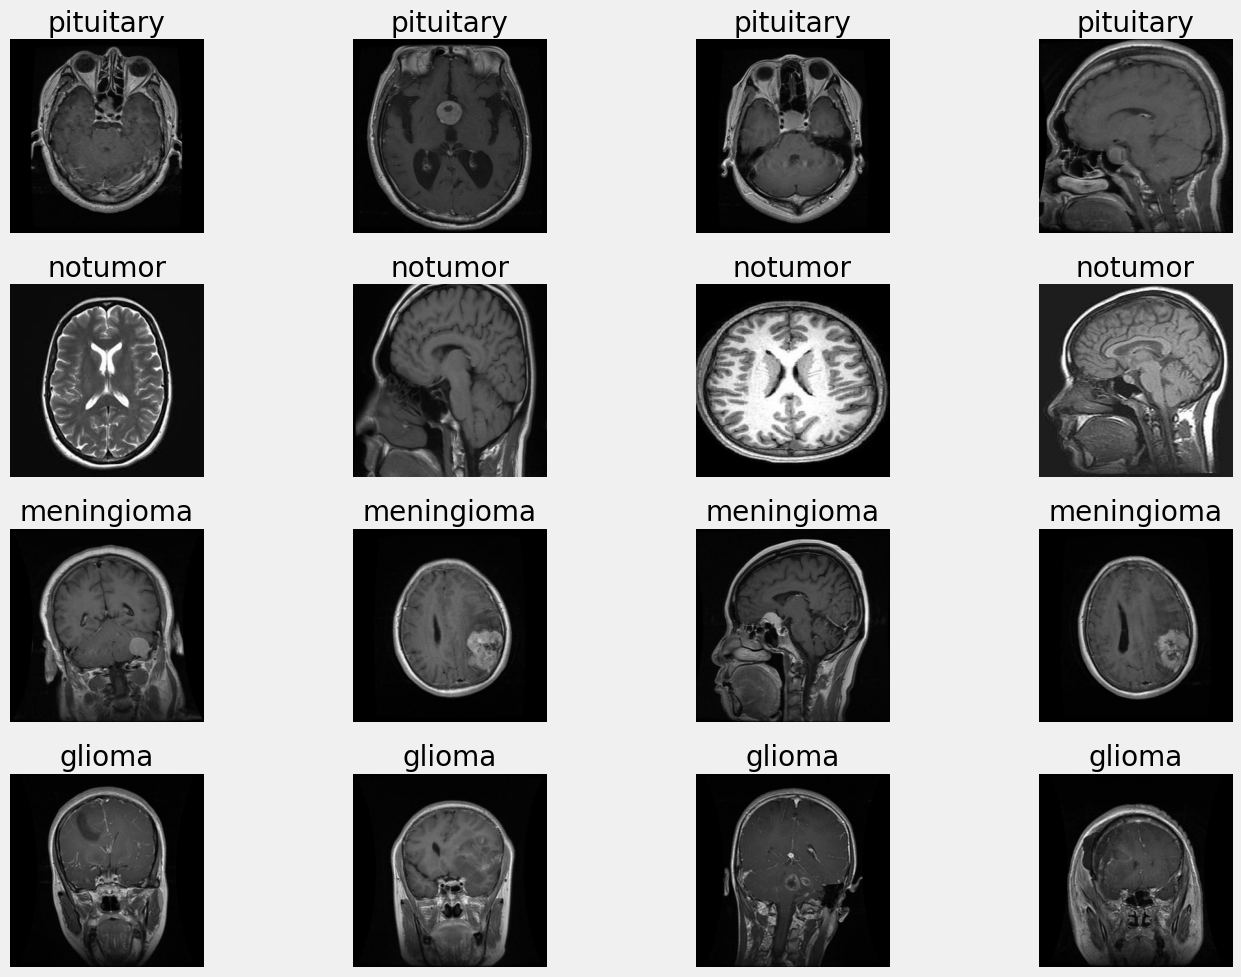

In [ ]:
plot_sample_iamges(Training)

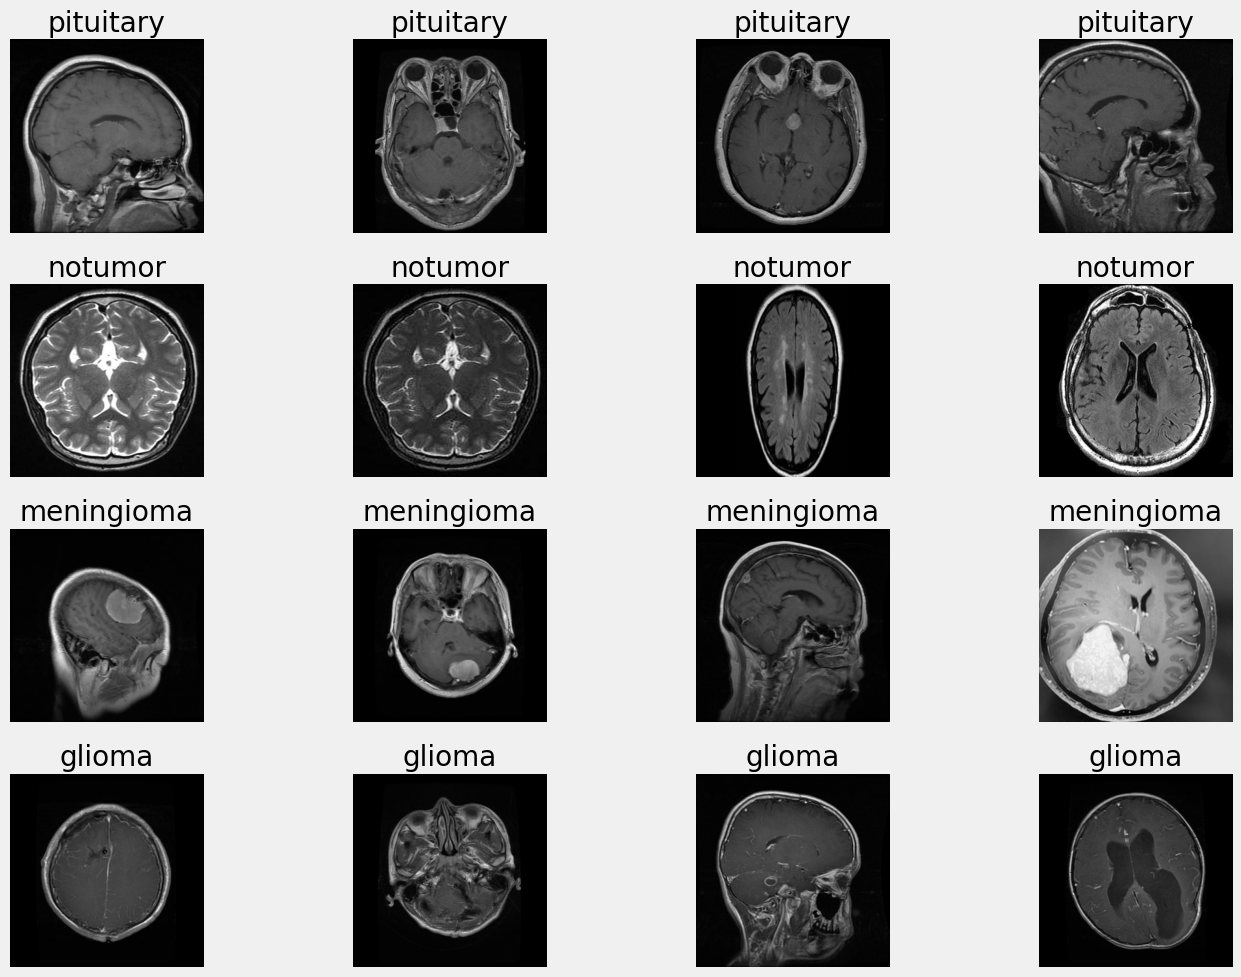

In [ ]:
plot_sample_iamges(Testing)

In [ ]:
def plot_class_distribution(datasettype):
    path = os.path.join(base_directory , datasettype)
    counts = [len(os.listdir(os.path.join(path , cat))) for cat in List_labels]

    plt.bar(List_labels , counts , color =['navy', 'teal', 'darkorange', 'crimson'])
    plt.xlabel("class")
    plt.ylabel("Number of Images")
    plt.title(f"{datasettype.capitalize()} Set Distribution")
    plt.show()

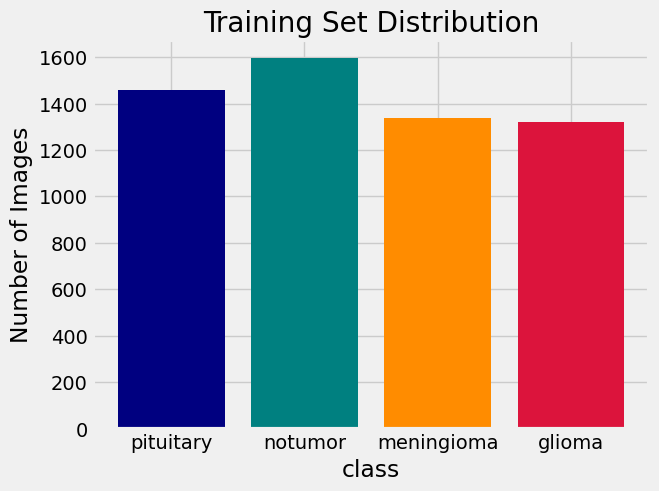

In [ ]:
plot_class_distribution(Training)

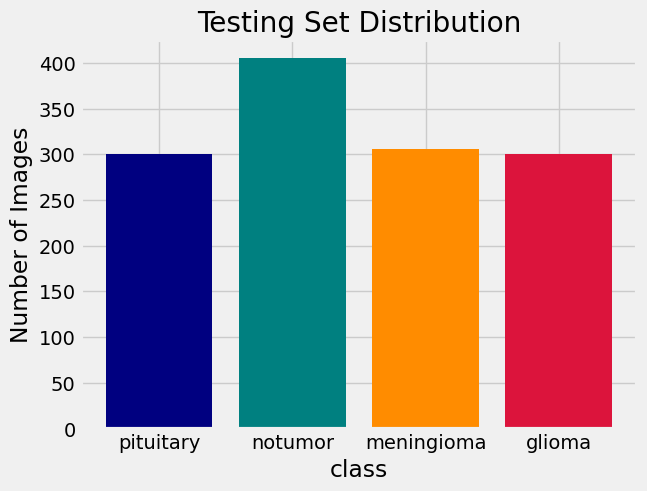

In [ ]:
plot_class_distribution(Testing)

In [ ]:
def create_dataset(path):
    my_list = []
    for label in List_labels:
        category_path = os.path.join(path , label)
        for file_name in os.listdir(category_path):
            image = os.path.join(category_path , file_name)
            if os.path.isfile(image) and image.lower().endswith(('.png', '.jpg', '.jpeg')):
                                my_list.append([image, label])
    return pd.DataFrame(my_list , columns = ['image' , 'label'])

In [ ]:
Train_df = create_dataset(base_directory+'/'+Training)
Test_df = create_dataset(base_directory+'/' + Testing)

In [ ]:
Train_df

,image,label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [ ]:
Train_df['label'] = Train_df['label'].map(labels)
Test_df['label'] = Test_df['label'].map(labels)

In [ ]:
Train_df

,image,label
0,/kaggle/input/brain-tumor-mri-dataset/Training...,0
1,/kaggle/input/brain-tumor-mri-dataset/Training...,0
2,/kaggle/input/brain-tumor-mri-dataset/Training...,0
3,/kaggle/input/brain-tumor-mri-dataset/Training...,0
4,/kaggle/input/brain-tumor-mri-dataset/Training...,0
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,3
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,3
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,3
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,3


In [ ]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
test_df , val_df = train_test_split(Test_df , test_size = 0.5 , random_state = 42)

test_df = test_df.reset_index(drop = True)

val_df = val_df.reset_index(drop = True)

In [ ]:
batch_size = 32
img_size = (299, 299)
_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(Train_df, x_col='image',
                                  y_col='label', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(val_df, x_col='image',
                                     y_col='label', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(test_df, x_col='image',
                                  y_col='label', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5712 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.


In [ ]:
img_shape=(299,299,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

# for layer in base_model.layers:
#     layer.trainable = False

model = keras.models.Sequential([
    base_model,
    Flatten(),
    Dropout(rate= 0.3),
    Dense(128, activation= 'relu'),
    Dropout(rate= 0.25),
    Dense(4, activation= 'softmax')
])

model.compile(Adamax(learning_rate= 0.001),
              loss= 'categorical_crossentropy',
              metrics= ['accuracy'])

model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
checkpoint = ModelCheckpoint('/kaggle/working/model_checkpoint.keras', save_best_only=True)
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 shuffle= False , callbacks=[checkpoint])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.6998 - loss: 0.7887 - val_accuracy: 0.9192 - val_loss: 0.2151
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 162s 907ms/step - accuracy: 0.9719 - loss: 0.0863 - val_accuracy: 0.9604 - val_loss: 0.1057
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 160s 895ms/step - accuracy: 0.9889 - loss: 0.0439 - val_accuracy: 0.9634 - val_loss: 0.1464
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 204s 908ms/step - accuracy: 0.9936 - loss: 0.0234 - val_accuracy: 0.9756 - val_loss: 0.1013
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 163s 907ms/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.9893 - val_loss: 0.0349
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 165s 922ms/step - accuracy: 0.9962 - loss: 0.0155 - val_accuracy: 0.9802 - val_loss: 0.0675
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 163s 908ms/step - accuracy: 0.9958 - loss: 0.0130 - val_accuracy: 0.9909 - val_loss: 0.0260
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 161s 896ms/step - accuracy: 0.9996 - lo

In [ ]:
history=hist.history

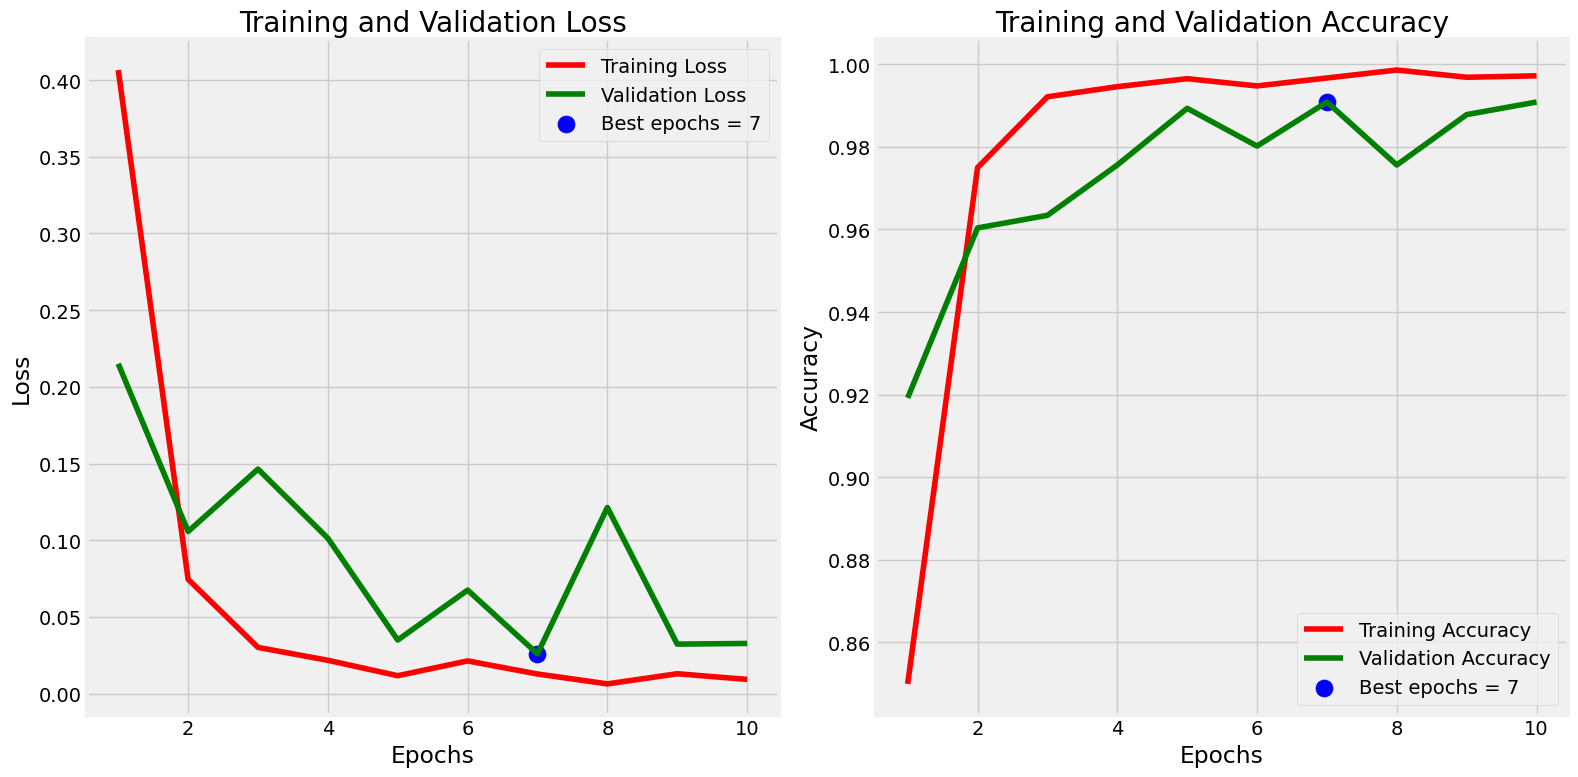

In [ ]:
train_acc = history['accuracy']
train_loss = history['loss']

val_acc = history['val_accuracy']
val_loss = history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

# Training history
plt.figure(figsize=(16,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue' , label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue' , label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.savefig('visulize_fr_MLP')
plt.legend()
plt.savefig('Brain_tumor_mob_net')
plt.tight_layout()
plt.show()

In [ ]:
best_model = load_model('/kaggle/working/model_checkpoint.keras')

In [ ]:
loss , acc = best_model.evaluate(ts_gen , verbose = 1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 334ms/step - accuracy: 0.9928 - loss: 0.0201


In [ ]:
print(f"Test Loss: {round(loss,2)}")
print(f"Test Accuracy: {round(acc*100,2)}%")

Test Loss: 0.03
Test Accuracy: 99.08%


In [ ]:
y_pred_prob = best_model.predict(ts_gen , verbose =1 )

41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step


In [ ]:
y_pred = np.argmax(y_pred_prob , axis = 1)

In [ ]:
print("\nClassification Report:\n", classification_report(ts_gen.labels, y_pred , target_names=['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']))


Classification Report:
               precision    recall  f1-score   support

      Glioma       0.99      0.99      0.99       151
  Meningioma       0.98      0.98      0.98       158
    No Tumor       0.99      1.00      1.00       197
   Pituitary       1.00      0.99      1.00       149

    accuracy                           0.99       655
   macro avg       0.99      0.99      0.99       655
weighted avg       0.99      0.99      0.99       655



In [ ]:
f1score = f1_score(ts_gen.labels, y_pred, average='macro')
precision=precision_score(ts_gen.labels, y_pred, average='macro')
recall = recall_score(ts_gen.labels, y_pred , average='macro')

In [ ]:
print(f"f1score: {round(f1score * 100. ,2)}%")
print(f"precision: {round(precision * 100 , 2)}%")
print(f"recall: {round(recall * 100 , 2)}%")

f1score: 99.05%
precision: 99.07%
recall: 99.03%


In [ ]:
cm = confusion_matrix(ts_gen.labels, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[149   2   0   0]
 [  2 155   1   0]
 [  0   0 197   0]
 [  0   1   0 148]]


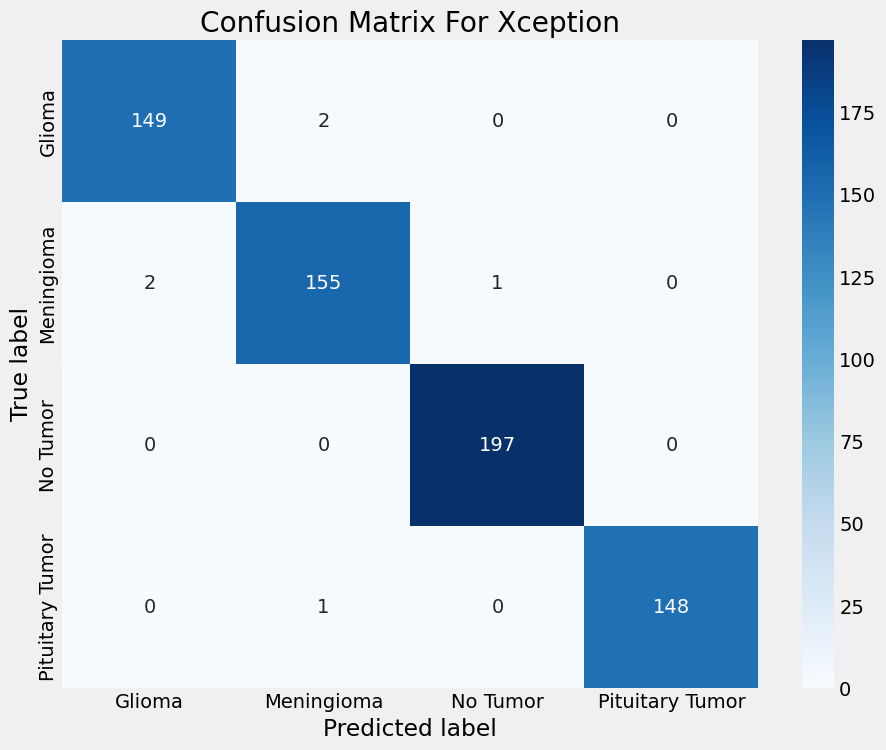

In [ ]:
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary Tumor']

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix For Xception")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.savefig('confusion matrix for Xception.png')
plt.show()

# Conclusion:

#### Now, the model detects brain tumor with:<br>
**99.08%** accuracy on the **test set**.<br>
**99.05%** f1 score on the **test set**.<br>
These resutls are very good considering that the data is balanced.


**Performance Table:**

| <!-- -->  | Validation set | Test set |
| --------- | -------------- | -------- |
| Accuracy  | 99.09%            | 99.08%      |
| F1 score  | 99.05%           | 99.05%    |